In [4]:
!pip install pytorch_forecasting
!pip install pytorch==2.10.0+cpu, numpy==2.0.2, pandas==2.2.2, xgboost==3.2.0
!pip install lightgbm==4.6.0, catboost==1.2.10, sklearn==1.6.1
!pip install pytabkit==1.7.3

ERROR: Could not find a version that satisfies the requirement pytorch==2.10.0+cpu (from versions: 0.1.2, 1.0.2)
ERROR: No matching distribution found for pytorch==2.10.0+cpu
ERROR: Ignored the following yanked versions: 0.0.post2
ERROR: Could not find a version that satisfies the requirement sklearn==1.6.1 (from versions: 0.0, 0.0.post1, 0.0.post4, 0.0.post5, 0.0.post7, 0.0.post9, 0.0.post10, 0.0.post11, 0.0.post12)
ERROR: No matching distribution found for sklearn==1.6.1


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from statsmodels.tsa.stattools import adfuller

from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin
from sklearn.model_selection import train_test_split, KFold, TimeSeriesSplit, cross_val_score
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans

import optuna
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from pytabkit import TabM_D_Regressor

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
import warnings
warnings.filterwarnings("ignore")
import pytorch_lightning as pl
from pytorch_forecasting import TimeSeriesDataSet, TiDEModel, Baseline
from pytorch_forecasting.data import GroupNormalizer, MultiNormalizer, EncoderNormalizer
from pytorch_forecasting.metrics import MAE, SMAPE, RMSE

In [6]:
def set_seed(seed=42):
    # Python
    random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # Pandas (через NumPy)
    pd.core.common.random_state(seed)

    # PyTorch (CPU)
    torch.manual_seed(seed)

    # PyTorch (GPU)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # CuDNN (детерминизм)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
SEED = 42
set_seed(SEED)

In [7]:
class ClipRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, regressor, low=0, up=90.09):
        self.regressor = regressor
        self.low = low
        self.up = up

    def fit(self, X, y):
        self.regressor.fit(X, y)
        return self

    def predict(self, X):
        pred = self.regressor.predict(X)
        return np.clip(pred, a_min=self.low, a_max=self.up)

    def get_params(self, deep=True):
        return {'regressor': self.regressor, 'low': self.low, 'up': self.up}

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

# Загрузка данных

In [ ]:
train = pd.read_csv("//kaggle/input/datasets/sergeyarefjev/wind-farm/train_dataset.csv")
train["METEOFORECASTHOUR_OPENM_Datetime"] = pd.to_datetime(
    train["METEOFORECASTHOUR_OPENM_Datetime"])
train.rename(columns={"METEOFORECASTHOUR_OPENM_Datetime": "timestamp",
                      "Кол-во_ВЭУ_в_ремонте": "count_repair",
                     "Выработка. Результирующий расчет": "power"}, inplace=True)
TARGET_COL = "power"
train.sort_values(["timestamp"], ascending=True, inplace=True)
print(train.shape)
train.head()

In [ ]:
valid = pd.read_csv("/kaggle/input/datasets/sergeyarefjev/wind-farm/valid_features.csv")
print(valid.shape)
valid["METEOFORECASTHOUR_OPENM_Datetime"] = pd.to_datetime(
    valid["METEOFORECASTHOUR_OPENM_Datetime"])
valid.rename(columns={"METEOFORECASTHOUR_OPENM_Datetime": "timestamp",
                      "Кол-во_ВЭУ_в_ремонте": "count_repair"}, inplace=True)
valid.sort_values(["timestamp"], ascending=True, inplace=True)
valid.head()

# ETL

(32434, 21)
(2126, 20)
Плотность добавлена!
Плотность добавлена!
Оценка влажности добавлена!
Оценка влажности добавлена!
['wind_direction_10m', 'wind_direction_80m', 'wind_direction_120m', 'wind_direction_180m', 'wind_direction_10m_meta', 'wind_direction_100m', 'wind_direction_10m_meta_1', 'wind_direction_100m_meta_1', 'wind_direction_10m_meta_2', 'wind_direction_100m_meta_2', 'wind_direction_10m_meta_3', 'wind_direction_100m_meta_3', 'wind_direction_10m_meta_4', 'wind_direction_100m_meta_4']
Синус-косинус кодирование добавлено!
Синус-косинус кодирование добавлено!
Характерестическая кривая для колонок: ['wind_speed_80m'] добавлена!
['wind_speed_10m', 'wind_speed_80m', 'wind_speed_120m', 'wind_speed_180m', 'wind_speed_10m_meta', 'wind_speed_100m', 'wind_speed_10m_meta_1', 'wind_speed_100m_meta_1', 'wind_speed_10m_meta_2', 'wind_speed_100m_meta_2', 'wind_speed_10m_meta_3', 'wind_speed_100m_meta_3', 'wind_speed_10m_meta_4', 'wind_speed_100m_meta_4', 'wind_speed_80m_cut', 'wind_speed_80m_

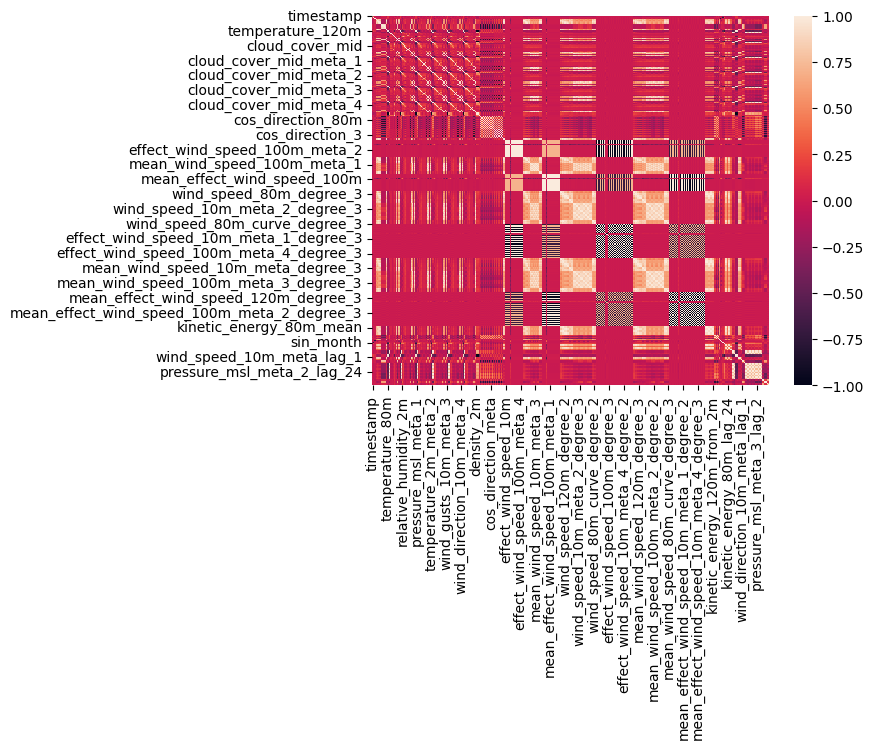

In [38]:
#ETL

##Загрузка данных

train = pd.read_csv("/kaggle/input/datasets/sergeyarefjev/wind-farm/train_dataset.csv")
train["METEOFORECASTHOUR_OPENM_Datetime"] = pd.to_datetime(
    train["METEOFORECASTHOUR_OPENM_Datetime"])
train.rename(columns={"METEOFORECASTHOUR_OPENM_Datetime": "timestamp",
                      "Кол-во_ВЭУ_в_ремонте": "count_repair",
                      "Выработка. Результирующий расчет": "power"}, inplace=True)
TARGET_COL = "power"
train.sort_values(["timestamp"], ascending=True, inplace=True)
train.reset_index(inplace=True)
train.drop(columns=["index"], inplace=True)
print(train.shape)
train.head()

valid = pd.read_csv("/kaggle/input/datasets/sergeyarefjev/wind-farm/valid_features.csv")
print(valid.shape)
valid["METEOFORECASTHOUR_OPENM_Datetime"] = pd.to_datetime(
    valid["METEOFORECASTHOUR_OPENM_Datetime"])
valid.rename(columns={"METEOFORECASTHOUR_OPENM_Datetime": "timestamp",
                      "Кол-во_ВЭУ_в_ремонте": "count_repair"}, inplace=True)
valid.sort_values(["timestamp"], ascending=True, inplace=True)
valid.reset_index(inplace=True)
valid.drop(columns=["index"], inplace=True)
valid.tail()

###Мета данные

parsing = False
flag_save = True
if parsing:
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": 46.8268455973,
        "longitude": 38.7179393185,
        "start_date": "2022-01-01",
        "end_date": "2026-04-01",
        "hourly": [
            "wind_speed_10m", "wind_speed_80m", "wind_speed_120m", "wind_speed_180m",
            "wind_direction_10m", "wind_direction_80m", "wind_direction_120m", "wind_direction_180m",
            "wind_gusts_10m",
            "temperature_2m", "temperature_80m", "temperature_120m",
            "pressure_msl", "relative_humidity_2m",
            "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
            "rain", "snowfall", "precipitation"
        ] + [f"wind_direction_{h}m" for h in range(0, 105, 5)] + [f"wind_speed_{h}m" for h in range(0, 105, 5)],
        "timezone": "Europe/Moscow"
    }

    response = requests.get(url, params=params)
    data = response.json()
    add_data_df = pd.DataFrame()

    for k, v in data["hourly"].items():
        add_data_df[k] = v

    colna = add_data_df.isna().sum() != 0
    colna = add_data_df.columns[colna]
    add_data_df.drop(columns=colna, inplace=True)
    for col in [col for col in add_data_df.columns if "speed" in col]:
        add_data_df[col] = add_data_df[col] / 3.6
    for col in [col for col in add_data_df.columns if "direction" in col]:
        add_data_df[col] = add_data_df[col] / 1000
    for col in ["relative_humidity_2m", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high"]:
        add_data_df[col] = add_data_df[col] / 100
    add_data_df["time"] = pd.to_datetime(add_data_df["time"])
    add_data_df["month"] = add_data_df["time"].dt.month
    add_data_df["hour_of_day"] = add_data_df["time"].dt.hour
    add_data_df.rename(columns={"time": "timestamp"}, inplace=True)
    add_data_df.head()

    if flag_save:
        add_data_df.to_csv("/content/drive/MyDrive/ML_data/wind_farm/meta_data_from_open_weather.csv")
else:
    add_data_df = pd.read_csv("/kaggle/input/datasets/sergeyarefjev/wind-farm/meta_data_from_open_weather.csv")
    add_data_df = add_data_df[add_data_df.columns[1:]]
    add_data_df["timestamp"] = pd.to_datetime(add_data_df["timestamp"])

use_columns_add_data = [col for col in add_data_df.columns if col not in ["month", "hour_of_day"]]
train = train.merge(add_data_df[use_columns_add_data], on="timestamp", how="left",
                    suffixes=("", "_meta"))
valid = valid.merge(add_data_df[use_columns_add_data], on="timestamp", how="left",
                    suffixes=("", "_meta"))

train.head()

#### Meta данные с соседних точек

parsing = False
flag_save = True
center = (48.8268455973, 38.7179393185)
points = [(center[0] + 0.1, center[1]), (center[0] - 0.1, center[1]),
            (center[0], center[1] + 0.1), (center[0], center[1] - 0.1)]
if parsing:
    url = "https://archive-api.open-meteo.com/v1/archive"
    for i, point in enumerate(points):

        params = {
            "latitude": point[0],
            "longitude": point[1],
            "start_date": "2022-01-01",
            "end_date": "2026-04-01",
            "hourly": [
                "wind_speed_10m", "wind_speed_80m", "wind_speed_120m", "wind_speed_180m",
                "wind_direction_10m", "wind_direction_80m", "wind_direction_120m", "wind_direction_180m",
                "wind_gusts_10m",
                "temperature_2m", "temperature_80m", "temperature_120m",
                "pressure_msl", "relative_humidity_2m",
                "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high",
                "rain", "snowfall", "precipitation"
            ] + [f"wind_direction_{h}m" for h in range(0, 105, 5)] + [f"wind_speed_{h}m" for h in range(0, 105, 5)],
            "timezone": "Europe/Moscow"
        }

        response = requests.get(url, params=params)
        data = response.json()
        add_data_df = pd.DataFrame()

        for k, v in data["hourly"].items():
            add_data_df[k] = v

        colna = add_data_df.isna().sum() != 0
        colna = add_data_df.columns[colna]
        add_data_df.drop(columns=colna, inplace=True)
        for col in [col for col in add_data_df.columns if "speed" in col]:
            add_data_df[col] = add_data_df[col] / 3.6
        for col in [col for col in add_data_df.columns if "direction" in col]:
            add_data_df[col] = add_data_df[col] / 1000
        for col in ["relative_humidity_2m", "cloud_cover_low", "cloud_cover_mid", "cloud_cover_high"]:
            add_data_df[col] = add_data_df[col] / 100
        add_data_df["time"] = pd.to_datetime(add_data_df["time"])
        add_data_df["month"] = add_data_df["time"].dt.month
        add_data_df["hour_of_day"] = add_data_df["time"].dt.hour
        add_data_df.rename(columns={"time": "timestamp"}, inplace=True)
        use_columns_add_data = [col for col in add_data_df.columns if col not in ["month", "hour_of_day"]]
        train = train.merge(add_data_df[use_columns_add_data], on="timestamp", how="left",
                            suffixes=("", f"_meta_{i + 1}"))
        valid = valid.merge(add_data_df[use_columns_add_data], on="timestamp", how="left",
                            suffixes=("", f"_meta_{i + 1}"))
        time.sleep(120)

        if flag_save:
            add_data_df.to_csv(f"/content/drive/MyDrive/ML_data/wind_farm/meta_data_from_open_weather_{i + 1}.csv")
else:
    for i in range(len(points)):
        add_data_df = pd.read_csv(f"/kaggle/input/datasets/sergeyarefjev/wind-farm/meta_data_from_open_weather_{i + 1}.csv")
        add_data_df = add_data_df[add_data_df.columns[1:]]
        add_data_df["timestamp"] = pd.to_datetime(add_data_df["timestamp"])
        use_columns_add_data = [col for col in add_data_df.columns if col not in ["month", "hour_of_day"]]
        train = train.merge(add_data_df[use_columns_add_data], on="timestamp", how="left",
                            suffixes=("", f"_meta_{i + 1}"))
        valid = valid.merge(add_data_df[use_columns_add_data], on="timestamp", how="left",
                            suffixes=("", f"_meta_{i + 1}"))

##Детекция и устранение аномалий


drop_start = True
if drop_start:
    train.dropna(inplace=True)

features = train.columns[4:]

iso = IsolationForest(
    contamination=0.02,
    random_state=SEED,
    n_estimators=500
    )
imputer = KNNImputer(
        n_neighbors=5,
        weights="distance"
    )

flag = iso.fit_predict(train[features]) == -1
train.loc[flag, features] = np.nan
#train[features] = imputer.fit_transform(train[features])
train.dropna(inplace=True)

"""
drop_start = True
if drop_start:
    train.dropna(inplace=True)

features = train.columns[4:]

iso = IsolationForest(
    contamination=0.02,
    random_state=SEED,
    n_estimators=500
    )
imputer = KNNImputer(
        n_neighbors=5,
        weights="distance"
    )
flag = iso.fit_predict(train[features]) == -1

each_column = False
if each_column:
    for col in features:
        flag = iso.fit_predict(train[col].values.reshape((-1, 1))) == -1
        train.loc[flag, col] = np.nan
        train[col] = imputer.fit_transform(train[col].values.reshape((-1, 1)))
else:
    flag = iso.fit_predict(train[features]) == -1
    train[flag] = np.nan
    train[features] = imputer.fit_transform(train[features])
    """

train.isna().sum()

##Feature Enginiring

use_meta = True
use_meta_neighbours = True

cols_meta_neighbors = [col for col in train.columns if "meta_" in col]

def add_density(data):
    if use_meta:
        data["density_2m"] = data["pressure_msl_meta"] / (data["temperature_2m"] + 273.15)
    data["density_80m"] = data["pressure_msl"] / (data["temperature_80m"] + 273.15)
    data["density_120m"] = data["pressure_msl"] / (data["temperature_120m"] + 273.15)
    print("Плотность добавлена!")
    return True

add_density(train)
add_density(valid)

def add_humidity(data):
    data["humidity"] = data["cloud_cover_low"].copy()
    cols = ["showers", "rain", "snowfall"]
    weights = [0.5, 0.2, 0.3]
    for col, w in zip(cols, weights):
        data["humidity"] += w * ((data[col] - data[col].min()) /
                                 (data[col].max() - data[col].min()))
    data["humidity"] = ((data["humidity"] - data["humidity"].min()) /
                        (data["humidity"].max() - data["humidity"].min()))
    print("Оценка влажности добавлена!")
    return True

add_humidity(train)
add_humidity(valid)

def add_sin_cos(data, columns):
    for col in columns:
        data[f"sin_direction_{col[col.rfind('_') + 1:]}"] = np.sin(
                                                data[col] * 1000 * np.pi / 180)
        data[f"cos_direction_{col[col.rfind('_') + 1:]}"] = np.cos(
                                                data[col] * 1000 * np.pi / 180)

    print("Синус-косинус кодирование добавлено!")
    return True

direction_cols = [col for col in train.columns if "wind_direction" in col and "lag" not in col]
if not use_meta_neighbours:
    direction_cols = [col for col in direction_cols if col not in cols_meta_neighbors]
print(direction_cols)

add_sin_cos(train, direction_cols)
add_sin_cos(valid, direction_cols)

def add_wind_curve(cols):
    for col in cols:
        train[f"{col}_cut"] = train[col].apply(lambda x: round(x))
        valid[f"{col}_cut"] = valid[col].apply(lambda x: round(x))
        wind_curve = train.groupby(f"{col}_cut").median()[TARGET_COL]
        max_col = np.max(wind_curve.index)
        for idx in range(max_col, 51):
            wind_curve[idx] = wind_curve[max_col]
        train[f"{col}_curve"] = train[f"{col}_cut"].apply(lambda x: wind_curve[x])
        valid[f"{col}_curve"] = valid[f"{col}_cut"].apply(lambda x: wind_curve[x])
        train.drop(columns=[f"{col}_cut"])
        valid.drop(columns=[f"{col}_cut"])
    print(f"Характерестическая кривая для колонок: {cols} добавлена!")
    return True

add_wind_curve(["wind_speed_80m"])

def add_effect_speed(data, columns, eps=1e-3):
    TI = (data["wind_gusts_10m"] - data["wind_speed_10m"]) / (data["wind_speed_10m"] + eps)
    if use_meta:
        TI_add = (data["wind_gusts_10m_meta"] - data["wind_speed_10m_meta"]) / (data["wind_speed_10m_meta"] + eps)
        TI = (TI + TI_add) / 2
    for col in columns:
        data[f"effect_{col}"] = data[col] * (1 - 0.5 * TI**2)
    print("Добавлена эффективная скорость ветра (с поправкой на турбулентность)!")
    return True

effect_columns = [col for col in train.columns if "speed" in col and "degree" not in col and "mean" not in col and "lag" not in col and "effect" not in col]
if not use_meta_neighbours:
    effect_columns = [col for col in effect_columns if col not in cols_meta_neighbors]
print(effect_columns)
add_effect_speed(train, effect_columns)
add_effect_speed(valid, effect_columns)

def add_mean_wind(columns):
    for col in columns:
        add_data = pd.concat([train, valid], axis=0)
        add_data[f"mean_{col}"] = (add_data[col] + add_data[col].shift(1)) / 2
        train[f"mean_{col}"] = add_data[f"mean_{col}"].iloc[:len(train)]
        valid[f"mean_{col}"] = add_data[f"mean_{col}"].iloc[len(train):]
    print("Средняя скорость за прошлый и нынешний час добавлена!")
    return True

speed_cols = [col for col in train.columns if "speed" in col and "degree" not in col and "mean" not in col and "lag" not in col]
if not use_meta_neighbours:
    speed_cols = [col for col in speed_cols if col not in cols_meta_neighbors]
print(speed_cols)

add_mean_wind(speed_cols)

def add_degree(data, columns):
    for col in columns:
        data[f"{col}_degree_2"] = data[col]**2
        data[f"{col}_degree_3"] = data[col]**3

    print("Степени добавлены!")
    return True

speed_cols = [col for col in train.columns if "speed" in col and "degree" not in col and "lag" not in col]
if not use_meta_neighbours:
    speed_cols = [col for col in speed_cols if col not in cols_meta_neighbors]
print(speed_cols)

add_degree(train, speed_cols)
add_degree(valid, speed_cols)

def add_kinetic_energy(data):
    for h in [80, 120]:
        data[f"kinetic_energy_{h}m"] = data[f"density_{h}m"] * data[f"wind_speed_{h}m_degree_3"]
        data[f"kinetic_energy_{h}m_mean"] = data[f"density_{h}m"] * data[f"mean_wind_speed_{h}m_degree_3"]
    if use_meta:
        for h in [80, 120]:
            data[f"kinetic_energy_{h}m_from_2m"] = data["density_2m"] * data[f"wind_speed_{h}m_degree_3"]
            data[f"kinetic_energy_{h}m_mean_from_2m"] = data["density_2m"] * data[f"wind_speed_{h}m_degree_3"]
    print("Кинетическая энергия добавлена!")
    return True

add_kinetic_energy(train)
add_kinetic_energy(valid)

def add_projection_enegry(data):
    for h in [80, 120]:
        data[f"sin_projection_energy_{h}m"] = (data[f"kinetic_energy_{h}m"] *
                                           data[f"sin_direction_{h}m"])
        data[f"cos_projection_energy_{h}m"] = (data[f"kinetic_energy_{h}m"] *
                                               data[f"cos_direction_{h}m"])
        if use_meta:
            data[f"sin_projection_energy_{h}m"] = (data[f"kinetic_energy_{h}m_from_2m"] *
                                            data[f"sin_direction_{h}m"])
            data[f"cos_projection_energy_{h}m"] = (data[f"kinetic_energy_{h}m_from_2m"] *
                                                data[f"cos_direction_{h}m"])
    print("Проекция энергии добавлена!") #используется оба кодирования, так как
    #ВЭС'ы стоят под разными углами
    return True

add_projection_enegry(train)
add_projection_enegry(valid)

def add_toggle(data, low=5, up=9):
    data["toggle"] = np.zeros(len(data))
    data["toggle"] = np.where(data["wind_speed_80m"] < low, 1, data["toggle"])
    data["toggle"] = np.where(data["wind_speed_80m"] > up, 3, data["toggle"])
    data["toggle"] = np.where((data["wind_speed_80m"] >= low) &
                                (data["wind_speed_80m"] <= up), 2, data["toggle"])
    print("Переключение добавлено!")
    return True



#Эти границы из документации
low = 3
up = 11
add_toggle(train, low=low, up=up)
add_toggle(valid, low=low, up=up)

def add_hour_seasonal(data):
    data["sin_hour"] = np.sin(data["hour_of_day"] / 24 * 2 * np.pi)
    data["cos_hour"] = np.cos(data["hour_of_day"] / 24 * 2 * np.pi)
    print("Синус-косинус преобразование для часов добавлено!")
    return True

add_hour_seasonal(train)
add_hour_seasonal(valid)

def add_month_seasonal(data):
    data["sin_month"] = np.sin(data["month"] / 12 * 2 * np.pi)
    data["cos_month"] = np.cos(data["month"] / 12 * 2 * np.pi)
    print("Синус-косинус кодирование для часов добавлено!")
    return True

add_month_seasonal(train)
add_month_seasonal(valid)

def add_shift_wind(data, eps=1e-5):
    data["shift_wind_10_80"] = np.log((data["wind_speed_80m"] + eps) / (data["wind_speed_10m"] + eps))
    data["shift_wind_80_120"] = np.log((data["wind_speed_120m"] + eps) / (data["wind_speed_80m"] + eps))
    data["shift_wind_120_180"] = np.log((data["wind_speed_180m"] + eps) / (data["wind_speed_120m"] + eps))
    print("Сдвиги ветра добавлены!")
    return True

test=False
if test:
    add_shift_wind(train)
    add_shift_wind(valid)

def add_sample_weights_from_valid(train_data_orig, test_data_orig):
    scaler = StandardScaler()
    train_data = scaler.fit_transform(train_data_orig)
    test_data = scaler.fit_transform(test_data_orig)
    center = np.mean(test_data, axis=0)

    dist = np.zeros(len(train_data))
    for i in range(train_data.shape[0]):
        dist[i] = np.sum(train_data[i] - center)
    dist_max = np.max(dist)
    dist_inverse = dist_max - dist
    train_weights = dist_inverse
    test_weights = 1
    return train_weights, test_weights

choice = False
if choice:
    all_features_cols = [col for col in train.columns if col not in [
    "timestamp", TARGET_COL
    ]]
    train.dropna(inplace=True)
    train["weights"], valid["weights"] = add_sample_weights_from_valid(train[all_features_cols], valid[all_features_cols])

def add_time_encoding(train, val):
    time_to_int = np.arange(len(train) + len(val))
    sin_encoding = np.sin(2 * np.pi * time_to_int / len(time_to_int))
    cos_encoding = np.cos(2 * np.pi * time_to_int / len(time_to_int))
    train["sin_time_encoding"] = sin_encoding[:len(train)]
    train["cos_time_encoding"] = cos_encoding[:len(train)]
    val["sin_time_encoding"] = sin_encoding[len(train):]
    val["cos_time_encoding"] = cos_encoding[len(train):]
    print("Синус-косинус кодирование времени добавлено")
    return True

#add_time_encoding(train, valid)

def add_lags(lags, columns):
    all_data = pd.concat([train, valid], axis=0)
    for col in columns:
        for lag in lags:
            all_data[f"{col}_{lag}"] = all_data[col].shift(lag)
            train[f"{col}_lag_{lag}"] = all_data[f"{col}_{lag}"].iloc[:len(train)]
            valid[f"{col}_lag_{lag}"] = all_data[f"{col}_{lag}"].iloc[len(train):]
    print(f"Лаги для колонок: {columns} добавлены!")
    return True

lags_columns = [
    "kinetic_energy_80m",
    "kinetic_energy_120m",
    "pressure_msl",
    "temperature_80m",
    "wind_speed_10m_meta",
    "wind_direction_10m_meta",
    "pressure_msl_meta"
]
if use_meta_neighbours:
    lags_columns = lags_columns + ["pressure_msl_meta_1",
                                   "pressure_msl_meta_2",
                                   "pressure_msl_meta_3",
                                   "pressure_msl_meta_4"]
add_lags([1, 2, 24], lags_columns)

def add_pressure_grad(data):
    for neig in [1, 2, 3, 4]:
        data[f"pressure_grad_{neig}_neig_1h"] = (data["pressure_msl"] -
                                                 data[f"pressure_msl_meta_{neig}_lag_1"])
    print("Пространственные градиенты добавлены!")
    return True
if  use_meta_neighbours:
    add_pressure_grad(train)
    add_pressure_grad(valid)

def add_sqrt_pressure(p_cols):
    """
    Введение этой фичи обусловленно эмпирическим правилом: V ~ sqrt(p)
    Оно работает лишь при сильных изменениях давления и дает оценку для
    порывов ветра
    """
    add_data = pd.concat([train, valid], axis=0)
    for p_col in p_cols:
        add_data[f"sqrt_diff_{p_col}"] = np.where(
            add_data[p_col] - add_data[p_col].shift(1) > 0,
            np.sqrt(add_data[p_col] - add_data[p_col].shift(1)),
        -np.sqrt(add_data[p_col].shift(1) - add_data[p_col]))
        train[f"sqrt_diff_{p_col}"] = add_data[f"sqrt_diff_{p_col}"].iloc[:len(train)]
        valid[f"sqrt_diff_{p_col}"] = add_data[f"sqrt_diff_{p_col}"].iloc[len(train)]
    print("Корень из разности давлений добавлен!")
    return True

add_sqrt_pressure(["pressure_msl", "pressure_msl_meta"])

small_features_cols = ["month", "hour_of_day", "count_repair", "wind_speed_10m",
                       "wind_speed_80m", "wind_speed_120m",
                       "sin_direction_10m", "sin_direction_80m",
                       "sin_direction_120m","cos_direction_10m",
                       "cos_direction_80m", "cos_direction_120m"]

small_features_and_degree_cols = small_features_cols + [
    col for col in train.columns if "degree" in col
]

lasso_01_features = ['month', 'hour_of_day', 'wind_speed_10m', 'wind_speed_80m',
    'wind_speed_120m','wind_speed_180m', 'wind_gusts_10m', 'temperature_80m',
    'pressure_msl', 'count_repair', 'sin_direction_10m', 'sin_direction_80m',
    'cos_direction_80m', 'sin_direction_120m', 'sin_direction_180m',
    'wind_speed_10m_degree_2', 'wind_speed_10m_degree_3', 'wind_speed_80m_degree_2',
    'wind_speed_80m_degree_3', 'wind_speed_120m_degree_2', 'wind_speed_120m_degree_3',
    'wind_speed_180m_degree_2', 'wind_speed_180m_degree_3']


lasso_01_features = ['month',
 'hour_of_day',
 'wind_speed_10m',
 'wind_speed_80m',
 'wind_speed_120m',
 'wind_speed_180m',
 'wind_gusts_10m',
 'temperature_80m',
 'pressure_msl',
 'count_repair',
 'sin_direction_10m',
 'sin_direction_80m',
 'cos_direction_80m',
 'sin_direction_120m',
 'sin_direction_180m',
 'wind_speed_10m_degree_2',
 'wind_speed_10m_degree_3',
 'wind_speed_80m_degree_2',
 'wind_speed_80m_degree_3',
 'wind_speed_120m_degree_2',
 'wind_speed_120m_degree_3',
 'wind_speed_180m_degree_2',
 'wind_speed_180m_degree_3',
 'sin_hour',
 'cos_hour',
 'sin_month',
 'cos_month']

lasso_03_features = ['month',
 'hour_of_day',
 'wind_speed_120m',
 'temperature_80m',
 'pressure_msl',
 'count_repair',
 'sin_direction_10m',
 'cos_direction_80m',
 'cos_direction_120m',
 'wind_speed_10m_degree_3',
 'wind_speed_80m_degree_2',
 'wind_speed_80m_degree_3',
 'wind_speed_120m_degree_2',
 'wind_speed_120m_degree_3',
 'wind_speed_180m_degree_2',
 'wind_speed_180m_degree_3']

lasso_0007_features = ['month',
 'hour_of_day',
 'wind_speed_10m',
 'wind_speed_80m',
 'wind_speed_120m',
 'wind_speed_180m',
 'wind_direction_10m',
 'wind_direction_120m',
 'wind_direction_180m',
 'wind_gusts_10m',
 'temperature_80m',
 'temperature_120m',
 'pressure_msl',
 'rain',
 'showers',
 'snowfall',
 'cloud_cover_low',
 'count_repair',
 'sin_direction_10m',
 'cos_direction_10m',
 'sin_direction_80m',
 'cos_direction_80m',
 'sin_direction_120m',
 'cos_direction_120m',
 'sin_direction_180m',
 'cos_direction_180m',
 'wind_speed_10m_degree_2',
 'wind_speed_10m_degree_3',
 'wind_speed_80m_degree_2',
 'wind_speed_80m_degree_3',
 'wind_speed_120m_degree_2',
 'wind_speed_120m_degree_3',
 'wind_speed_180m_degree_2',
 'wind_speed_180m_degree_3',
 'toggle',
 'sin_hour',
 'cos_hour',
 'sin_month',
 'cos_month',
 'shift_wind_10_80',
 'shift_wind_80_120',
 'shift_wind_120_180']

hill_climb_from_random = ['month',
 'hour_of_day',
 'wind_speed_10m',
 'wind_speed_80m',
 'wind_speed_180m',
 'wind_direction_10m',
 'wind_gusts_10m',
 'temperature_120m',
 'rain',
 'showers',
 'cloud_cover_low',
 'count_repair',
 'humidity',
 'sin_direction_120m',
 'mean_wind_speed_180m',
 'wind_speed_10m_degree_2',
 'wind_speed_10m_degree_3',
 'mean_wind_speed_10m_degree_3',
 'mean_wind_speed_120m_degree_2',
 'kinetic_energy_80m',
 'kinetic_energy_120m',
 'kinetic_energy_120m_mean',
 'cos_hour',
 'cos_month']

hill_climb_from_random_meta = ['hour_of_day',
 'wind_speed_80m',
 'wind_speed_180m',
 'wind_direction_80m',
 'wind_gusts_10m',
 'temperature_80m',
 'temperature_120m',
 'rain',
 'cloud_cover_low',
 'count_repair',
 'wind_gusts_10m_meta',
 'cloud_cover_mid',
 'rain_meta',
 'snowfall_meta',
 'density_120m',
 'sin_direction_10m',
 'sin_direction_120m',
 'cos_direction_120m',
 'cos_direction_100m',
 'effect_wind_speed_100m',
 'mean_wind_speed_80m',
 'mean_wind_speed_120m',
 'mean_effect_wind_speed_100m',
 'wind_speed_10m_degree_3',
 'wind_speed_180m_degree_3',
 'wind_speed_10m_meta_degree_2',
 'wind_speed_100m_degree_3',
 'effect_wind_speed_10m_degree_2',
 'effect_wind_speed_10m_degree_3',
 'effect_wind_speed_120m_degree_2',
 'effect_wind_speed_180m_degree_2',
 'effect_wind_speed_180m_degree_3',
 'effect_wind_speed_10m_meta_degree_3',
 'effect_wind_speed_100m_degree_2',
 'mean_wind_speed_10m_degree_2',
 'mean_wind_speed_80m_degree_2',
 'mean_wind_speed_120m_degree_2',
 'mean_wind_speed_180m_degree_3',
 'mean_wind_speed_100m_degree_2',
 'mean_wind_speed_100m_degree_3',
 'mean_effect_wind_speed_180m_degree_2',
 'mean_effect_wind_speed_180m_degree_3',
 'mean_effect_wind_speed_10m_meta_degree_2',
 'kinetic_energy_120m',
 'kinetic_energy_120m_from_2m',
 'sin_projection_energy_120m',
 'toggle',
 'sin_hour',
 'cos_month',
 'kinetic_energy_80m_lag_24',
 'kinetic_energy_120m_lag_1',
 'kinetic_energy_120m_lag_2',
 'kinetic_energy_120m_lag_24',
 'pressure_msl_lag_24',
 'temperature_80m_lag_24']

hill_climb_from_lasso = ['wind_speed_10m',
 'wind_speed_120m',
 'wind_speed_180m',
 'wind_direction_10m',
 'wind_gusts_10m',
 'temperature_80m',
 'showers',
 'cloud_cover_low',
 'count_repair',
 'sin_direction_80m',
 'cos_direction_80m',
 'sin_direction_180m',
 'wind_speed_10m_degree_2',
 'wind_speed_10m_degree_3',
 'wind_speed_80m_degree_2',
 'wind_speed_80m_degree_3',
 'wind_speed_120m_degree_2',
 'wind_speed_120m_degree_3',
 'wind_speed_180m_degree_2',
 'wind_speed_180m_degree_3',
 'toggle',
 'sin_hour',
 'cos_hour',
 'sin_month',
 'cos_month',
 'shift_wind_10_80']

hill_climb_from_all = ['hour_of_day',
 'wind_speed_80m',
 'wind_speed_120m',
 'wind_direction_10m',
 'wind_gusts_10m',
 'temperature_120m',
 'rain',
 'showers',
 'snowfall',
 'cloud_cover_low',
 'count_repair',
 'sin_direction_10m',
 'cos_direction_10m',
 'cos_direction_80m',
 'sin_direction_120m',
 'cos_direction_120m',
 'sin_direction_180m',
 'wind_speed_10m_degree_2',
 'wind_speed_10m_degree_3',
 'wind_speed_80m_degree_2',
 'wind_speed_80m_degree_3',
 'wind_speed_120m_degree_2',
 'wind_speed_120m_degree_3',
 'wind_speed_180m_degree_2',
 'wind_speed_180m_degree_3',
 'toggle',
 'sin_hour',
 'cos_hour',
 'sin_month',
 'cos_month',
 'shift_wind_10_80',
 'shift_wind_80_120',
 'shift_wind_120_180']

hill_climb_from_all_meta=['month',
 'wind_speed_10m',
 'wind_speed_80m',
 'wind_speed_120m',
 'wind_speed_180m',
 'wind_direction_10m',
 'wind_direction_80m',
 'wind_direction_120m',
 'wind_direction_180m',
 'wind_gusts_10m',
 'temperature_80m',
 'temperature_120m',
 'pressure_msl',
 'showers',
 'snowfall',
 'cloud_cover_low',
 'count_repair',
 'wind_speed_10m_meta',
 'wind_direction_10m_meta',
 'wind_gusts_10m_meta',
 'temperature_2m',
 'pressure_msl_meta',
 'relative_humidity_2m',
 'cloud_cover_low_meta',
 'cloud_cover_mid',
 'cloud_cover_high',
 'rain_meta',
 'snowfall_meta',
 'precipitation',
 'wind_direction_100m',
 'wind_speed_100m',
 #'month_meta',
# 'hour_of_day_meta',
 'density_2m',
 'density_80m',
 'density_120m',
 'humidity',
 'sin_direction_10m',
 'cos_direction_10m',
 'sin_direction_80m',
 'cos_direction_80m',
 'sin_direction_120m',
 'cos_direction_120m',
 'sin_direction_180m',
 'cos_direction_180m',
 'sin_direction_meta',
 'cos_direction_meta',
 'sin_direction_100m',
 'cos_direction_100m',
 'effect_wind_speed_10m',
 'effect_wind_speed_80m',
 'effect_wind_speed_120m',
 'effect_wind_speed_180m',
 'effect_wind_speed_10m_meta',
 'effect_wind_speed_100m',
 'mean_wind_speed_10m',
 'mean_wind_speed_80m',
 'mean_wind_speed_120m',
 'mean_wind_speed_180m',
 'mean_wind_speed_10m_meta',
 'mean_wind_speed_100m',
 'mean_effect_wind_speed_10m',
 'mean_effect_wind_speed_80m',
 'mean_effect_wind_speed_120m',
 'mean_effect_wind_speed_180m',
 'mean_effect_wind_speed_10m_meta',
 'mean_effect_wind_speed_100m',
 'wind_speed_10m_degree_2',
 'wind_speed_10m_degree_3',
 'wind_speed_80m_degree_2',
 'wind_speed_80m_degree_3',
 'wind_speed_120m_degree_2',
 'wind_speed_120m_degree_3',
 'wind_speed_180m_degree_2',
 'wind_speed_180m_degree_3',
 'wind_speed_10m_meta_degree_2',
 'wind_speed_10m_meta_degree_3',
 'wind_speed_100m_degree_2',
 'wind_speed_100m_degree_3',
 'effect_wind_speed_10m_degree_2',
 'effect_wind_speed_10m_degree_3',
 'effect_wind_speed_80m_degree_2',
 'effect_wind_speed_80m_degree_3',
 'effect_wind_speed_120m_degree_2',
 'effect_wind_speed_120m_degree_3',
 'effect_wind_speed_180m_degree_2',
 'effect_wind_speed_180m_degree_3',
 'effect_wind_speed_10m_meta_degree_2',
 'effect_wind_speed_10m_meta_degree_3',
 'effect_wind_speed_100m_degree_2',
 'effect_wind_speed_100m_degree_3',
 'mean_wind_speed_10m_degree_2',
 'mean_wind_speed_10m_degree_3',
 'mean_wind_speed_80m_degree_2',
 'mean_wind_speed_80m_degree_3',
 'mean_wind_speed_120m_degree_2',
 'mean_wind_speed_120m_degree_3',
 'mean_wind_speed_180m_degree_2',
 'mean_wind_speed_180m_degree_3',
 'mean_wind_speed_10m_meta_degree_2',
 'mean_wind_speed_10m_meta_degree_3',
 'mean_wind_speed_100m_degree_2',
 'mean_wind_speed_100m_degree_3',
 'mean_effect_wind_speed_10m_degree_2',
 'mean_effect_wind_speed_10m_degree_3',
 'mean_effect_wind_speed_80m_degree_2',
 'mean_effect_wind_speed_80m_degree_3',
 'mean_effect_wind_speed_120m_degree_2',
 'mean_effect_wind_speed_120m_degree_3',
 'mean_effect_wind_speed_180m_degree_2',
 'mean_effect_wind_speed_180m_degree_3',
 'mean_effect_wind_speed_10m_meta_degree_2',
 'mean_effect_wind_speed_10m_meta_degree_3',
 'mean_effect_wind_speed_100m_degree_2',
 'mean_effect_wind_speed_100m_degree_3',
 'kinetic_energy_80m',
 'kinetic_energy_80m_mean',
 'kinetic_energy_120m',
 'kinetic_energy_120m_mean',
 'kinetic_energy_80m_from_2m',
 'kinetic_energy_80m_mean_from_2m',
 'kinetic_energy_120m_from_2m',
 'kinetic_energy_120m_mean_from_2m',
 'sin_projection_energy_80m',
 'cos_projection_energy_80m',
 'sin_projection_energy_120m',
 'cos_projection_energy_120m',
 'toggle',
 'sin_hour',
 'cos_hour',
 'sin_month',
 'cos_month',
 'kinetic_energy_80m_lag_1',
 'kinetic_energy_80m_lag_2',
 'kinetic_energy_80m_lag_24',
 'kinetic_energy_120m_lag_1',
 'kinetic_energy_120m_lag_2',
 'kinetic_energy_120m_lag_24',
 'pressure_msl_lag_1',
 'pressure_msl_lag_2',
 'pressure_msl_lag_24',
 'temperature_80m_lag_1',
 'temperature_80m_lag_2',
 'temperature_80m_lag_24',
 'wind_speed_10m_meta_lag_1',
 'wind_speed_10m_meta_lag_2',
 'wind_speed_10m_meta_lag_24',
 'wind_direction_10m_meta_lag_1',
 'wind_direction_10m_meta_lag_2',
 'wind_direction_10m_meta_lag_24',
 'sqrt_diff_pressure_msl',
 'sqrt_diff_pressure_msl_meta']

hill_climb_from_random_07_meta = ['wind_speed_10m',
 'wind_speed_120m',
 'wind_speed_180m',
 'wind_direction_10m',
 'wind_direction_80m',
 'wind_direction_120m',
 'wind_direction_180m',
 'wind_gusts_10m',
 'temperature_80m',
 'temperature_120m',
 'pressure_msl',
 'rain',
 'showers',
 'snowfall',
 'cloud_cover_low',
 'count_repair',
 'wind_speed_10m_meta',
 'wind_direction_10m_meta',
 'temperature_2m',
 'pressure_msl_meta',
 'relative_humidity_2m',
 'cloud_cover_low_meta',
 'cloud_cover_mid',
 'cloud_cover_high',
 'rain_meta',
 'snowfall_meta',
 'precipitation',
 'wind_direction_100m',
 'wind_speed_100m',
 #'month_meta',
 #'hour_of_day_meta',
 'density_2m',
 'density_80m',
 'density_120m',
 'humidity',
 'sin_direction_10m',
 'sin_direction_80m',
 'cos_direction_80m',
 'sin_direction_120m',
 'cos_direction_120m',
 'sin_direction_180m',
 'cos_direction_180m',
 'sin_direction_meta',
 'cos_direction_meta',
 'sin_direction_100m',
 'cos_direction_100m',
 'wind_speed_80m_cut',
 'wind_speed_80m_curve',
 'effect_wind_speed_10m',
 'effect_wind_speed_80m',
 'effect_wind_speed_120m',
 'effect_wind_speed_180m',
 'effect_wind_speed_10m_meta',
 'effect_wind_speed_100m',
 'effect_wind_speed_80m_cut',
 'effect_wind_speed_80m_curve',
 'mean_wind_speed_10m',
 'mean_wind_speed_80m',
 'mean_wind_speed_120m',
 'mean_wind_speed_180m',
 'mean_wind_speed_10m_meta',
 'mean_wind_speed_100m',
 'mean_wind_speed_80m_cut',
 'mean_wind_speed_80m_curve',
 'mean_effect_wind_speed_10m',
 'mean_effect_wind_speed_80m',
 'mean_effect_wind_speed_120m',
 'mean_effect_wind_speed_180m',
 'mean_effect_wind_speed_10m_meta',
 'mean_effect_wind_speed_100m',
 'mean_effect_wind_speed_80m_cut',
 'mean_effect_wind_speed_80m_curve',
 'wind_speed_10m_degree_2',
 'wind_speed_10m_degree_3',
 'wind_speed_80m_degree_2',
 'wind_speed_80m_degree_3',
 'wind_speed_120m_degree_2',
 'wind_speed_120m_degree_3',
 'wind_speed_180m_degree_2',
 'wind_speed_180m_degree_3',
 'wind_speed_10m_meta_degree_2',
 'wind_speed_10m_meta_degree_3',
 'wind_speed_100m_degree_2',
 'wind_speed_100m_degree_3',
 'wind_speed_80m_cut_degree_2',
 'wind_speed_80m_cut_degree_3',
 'wind_speed_80m_curve_degree_2',
 'wind_speed_80m_curve_degree_3',
 'effect_wind_speed_10m_degree_2',
 'effect_wind_speed_10m_degree_3',
 'effect_wind_speed_80m_degree_2',
 'effect_wind_speed_80m_degree_3',
 'effect_wind_speed_120m_degree_2',
 'effect_wind_speed_120m_degree_3',
 'effect_wind_speed_180m_degree_2',
 'effect_wind_speed_180m_degree_3',
 'effect_wind_speed_10m_meta_degree_2',
 'effect_wind_speed_10m_meta_degree_3',
 'effect_wind_speed_100m_degree_2',
 'effect_wind_speed_100m_degree_3',
 'effect_wind_speed_80m_cut_degree_2',
 'effect_wind_speed_80m_cut_degree_3',
 'effect_wind_speed_80m_curve_degree_2',
 'effect_wind_speed_80m_curve_degree_3',
 'mean_wind_speed_10m_degree_2',
 'mean_wind_speed_10m_degree_3',
 'mean_wind_speed_80m_degree_2',
 'mean_wind_speed_80m_degree_3',
 'mean_wind_speed_120m_degree_2',
 'mean_wind_speed_120m_degree_3',
 'mean_wind_speed_180m_degree_2',
 'mean_wind_speed_180m_degree_3',
 'mean_wind_speed_10m_meta_degree_2',
 'mean_wind_speed_10m_meta_degree_3',
 'mean_wind_speed_100m_degree_2',
 'mean_wind_speed_100m_degree_3',
 'mean_wind_speed_80m_cut_degree_2',
 'mean_wind_speed_80m_cut_degree_3',
 'mean_wind_speed_80m_curve_degree_2',
 'mean_wind_speed_80m_curve_degree_3',
 'mean_effect_wind_speed_10m_degree_2',
 'mean_effect_wind_speed_10m_degree_3',
 'mean_effect_wind_speed_80m_degree_2',
 'mean_effect_wind_speed_80m_degree_3',
 'mean_effect_wind_speed_120m_degree_2',
 'mean_effect_wind_speed_120m_degree_3',
 'mean_effect_wind_speed_180m_degree_2',
 'mean_effect_wind_speed_180m_degree_3',
 'mean_effect_wind_speed_10m_meta_degree_2',
 'mean_effect_wind_speed_10m_meta_degree_3',
 'mean_effect_wind_speed_100m_degree_2',
 'mean_effect_wind_speed_100m_degree_3',
 'mean_effect_wind_speed_80m_cut_degree_2',
 'mean_effect_wind_speed_80m_cut_degree_3',
 'mean_effect_wind_speed_80m_curve_degree_2',
 'mean_effect_wind_speed_80m_curve_degree_3',
 'kinetic_energy_80m',
 'kinetic_energy_80m_mean',
 'kinetic_energy_120m',
 'kinetic_energy_120m_mean',
 'kinetic_energy_80m_from_2m',
 'kinetic_energy_80m_mean_from_2m',
 'kinetic_energy_120m_from_2m',
 'kinetic_energy_120m_mean_from_2m',
 'sin_projection_energy_80m',
 'cos_projection_energy_80m',
 'sin_projection_energy_120m',
 'cos_projection_energy_120m',
 'toggle',
 'sin_hour',
 'cos_hour',
 'sin_month',
 'cos_month',
 'kinetic_energy_80m_lag_1',
 'kinetic_energy_80m_lag_2',
 'kinetic_energy_80m_lag_24',
 'kinetic_energy_120m_lag_1',
 'kinetic_energy_120m_lag_2',
 'kinetic_energy_120m_lag_24',
 'pressure_msl_lag_1',
 'pressure_msl_lag_2',
 'pressure_msl_lag_24',
 'temperature_80m_lag_1',
 'temperature_80m_lag_2',
 'temperature_80m_lag_24',
 'wind_speed_10m_meta_lag_1',
 'wind_speed_10m_meta_lag_2',
 'wind_speed_10m_meta_lag_24',
 'wind_direction_10m_meta_lag_1',
 'wind_direction_10m_meta_lag_2',
 'wind_direction_10m_meta_lag_24',
 'sqrt_diff_pressure_msl',
 'sqrt_diff_pressure_msl_meta']

hill_climb_from_meta_meta = ['wind_direction_10m',
 'wind_direction_80m',
 'wind_direction_120m',
 'wind_gusts_10m',
 'temperature_120m',
 'pressure_msl',
 'rain',
 'showers',
 'snowfall',
 'cloud_cover_low',
 'count_repair',
 'wind_speed_10m_meta',
 'wind_direction_10m_meta',
 'pressure_msl_meta',
 'cloud_cover_low_meta',
 'cloud_cover_mid',
 'cloud_cover_high',
 'rain_meta',
 'snowfall_meta',
 'precipitation',
 'wind_direction_100m',
 'wind_speed_100m',
 'wind_speed_10m_meta_1',
 'cloud_cover_low_meta_1',
 'density_2m',
 'density_80m',
 'density_120m',
 'humidity',
 'sin_direction_10m',
 'sin_direction_80m',
 'cos_direction_80m',
 'sin_direction_120m',
 'cos_direction_120m',
 'sin_direction_180m',
 'cos_direction_180m',
 'sin_direction_meta',
 'cos_direction_meta',
 'sin_direction_100m',
 'cos_direction_100m',
 'wind_speed_80m_cut',
 'wind_speed_80m_curve',
 'effect_wind_speed_10m',
 'effect_wind_speed_80m',
 'effect_wind_speed_120m',
 'effect_wind_speed_180m',
 'effect_wind_speed_10m_meta',
 'effect_wind_speed_100m',
 'effect_wind_speed_80m_cut',
 'effect_wind_speed_80m_curve',
 'mean_wind_speed_10m',
 'mean_wind_speed_80m',
 'mean_wind_speed_120m',
 'mean_wind_speed_180m',
 'mean_wind_speed_10m_meta',
 'mean_wind_speed_100m',
 'mean_wind_speed_80m_cut',
 'mean_wind_speed_80m_curve',
 'mean_effect_wind_speed_10m',
 'mean_effect_wind_speed_80m',
 'mean_effect_wind_speed_120m',
 'mean_effect_wind_speed_180m',
 'mean_effect_wind_speed_10m_meta',
 'mean_effect_wind_speed_100m',
 'mean_effect_wind_speed_80m_cut',
 'mean_effect_wind_speed_80m_curve',
 'wind_speed_10m_degree_2',
 'wind_speed_10m_degree_3',
 'wind_speed_80m_degree_2',
 'wind_speed_80m_degree_3',
 'wind_speed_120m_degree_2',
 'wind_speed_120m_degree_3',
 'wind_speed_180m_degree_2',
 'wind_speed_180m_degree_3',
 'wind_speed_10m_meta_degree_2',
 'wind_speed_10m_meta_degree_3',
 'wind_speed_100m_degree_2',
 'wind_speed_100m_degree_3',
 'wind_speed_80m_cut_degree_2',
 'wind_speed_80m_cut_degree_3',
 'wind_speed_80m_curve_degree_2',
 'wind_speed_80m_curve_degree_3',
 'effect_wind_speed_10m_degree_2',
 'effect_wind_speed_10m_degree_3',
 'effect_wind_speed_80m_degree_2',
 'effect_wind_speed_80m_degree_3',
 'effect_wind_speed_120m_degree_3',
 'effect_wind_speed_180m_degree_2',
 'effect_wind_speed_180m_degree_3',
 'effect_wind_speed_10m_meta_degree_2',
 'effect_wind_speed_10m_meta_degree_3',
 'effect_wind_speed_100m_degree_2',
 'effect_wind_speed_100m_degree_3',
 'effect_wind_speed_80m_cut_degree_2',
 'effect_wind_speed_80m_cut_degree_3',
 'effect_wind_speed_80m_curve_degree_2',
 'effect_wind_speed_80m_curve_degree_3',
 'mean_wind_speed_10m_degree_2',
 'mean_wind_speed_10m_degree_3',
 'mean_wind_speed_80m_degree_2',
 'mean_wind_speed_80m_degree_3',
 'mean_wind_speed_120m_degree_2',
 'mean_wind_speed_120m_degree_3',
 'mean_wind_speed_180m_degree_2',
 'mean_wind_speed_180m_degree_3',
 'mean_wind_speed_10m_meta_degree_2',
 'mean_wind_speed_10m_meta_degree_3',
 'mean_wind_speed_100m_degree_2',
 'mean_wind_speed_100m_degree_3',
 'mean_wind_speed_80m_cut_degree_2',
 'mean_wind_speed_80m_cut_degree_3',
 'mean_wind_speed_80m_curve_degree_2',
 'mean_wind_speed_80m_curve_degree_3',
 'mean_effect_wind_speed_10m_degree_2',
 'mean_effect_wind_speed_10m_degree_3',
 'mean_effect_wind_speed_80m_degree_2',
 'mean_effect_wind_speed_80m_degree_3',
 'mean_effect_wind_speed_120m_degree_2',
 'mean_effect_wind_speed_120m_degree_3',
 'mean_effect_wind_speed_180m_degree_2',
 'mean_effect_wind_speed_180m_degree_3',
 'mean_effect_wind_speed_10m_meta_degree_2',
 'mean_effect_wind_speed_10m_meta_degree_3',
 'mean_effect_wind_speed_100m_degree_2',
 'mean_effect_wind_speed_100m_degree_3',
 'mean_effect_wind_speed_80m_cut_degree_2',
 'mean_effect_wind_speed_80m_cut_degree_3',
 'mean_effect_wind_speed_80m_curve_degree_2',
 'mean_effect_wind_speed_80m_curve_degree_3',
 'kinetic_energy_80m',
 'kinetic_energy_80m_mean',
 'kinetic_energy_120m',
 'kinetic_energy_120m_mean',
 'kinetic_energy_80m_from_2m',
 'kinetic_energy_80m_mean_from_2m',
 'kinetic_energy_120m_from_2m',
 'kinetic_energy_120m_mean_from_2m',
 'sin_projection_energy_80m',
 'cos_projection_energy_80m',
 'sin_projection_energy_120m',
 'cos_projection_energy_120m',
 'toggle',
 'sin_hour',
 'cos_hour',
 'sin_month',
 'cos_month',
 'kinetic_energy_80m_lag_1',
 'kinetic_energy_80m_lag_2',
 'kinetic_energy_80m_lag_24',
 'kinetic_energy_120m_lag_1',
 'kinetic_energy_120m_lag_2',
 'kinetic_energy_120m_lag_24',
 'pressure_msl_lag_1',
 'pressure_msl_lag_2',
 'pressure_msl_lag_24',
 'temperature_80m_lag_1',
 'temperature_80m_lag_2',
 'temperature_80m_lag_24',
 'wind_speed_10m_meta_lag_1',
 'wind_speed_10m_meta_lag_2',
 'wind_speed_10m_meta_lag_24',
 'wind_direction_10m_meta_lag_1',
 'wind_direction_10m_meta_lag_2',
 'wind_direction_10m_meta_lag_24',
 'pressure_msl_meta_1_lag_2',
 'sqrt_diff_pressure_msl',
 'sqrt_diff_pressure_msl_meta']

lasso_01_features_plus_toggle = lasso_01_features + ["toggle"]

lasso_01_features_plus_toggle_and_seasonal_hour = lasso_01_features + ["sin_hour", "cos_hour", "toggle"]
lasso_01_features_plus_toggle_and_seasonal_hour = [col for col in lasso_01_features_plus_toggle_and_seasonal_hour if col != "hour_of_day"]

all_features_cols = [col for col in train.columns if col not in [
    "timestamp", TARGET_COL, "time_idx"
]]
all_features_cols_without_degree = [col for col in all_features_cols
                                if "degree" not in col] #Степени помогают

small_features_and_degree_cols

sns.heatmap(train.corr())

###Разделение на train/val

def time_split(percent_val=0.2):
    length_train = int(len(train) * (1 - percent_val))

    train_model = train.iloc[:length_train]
    val_model = train.iloc[length_train:]
    return train_model, val_model

def random_split(percent_val=0.2):
    x_train, x_val, y_train, y_val = train_test_split(
        train[[col for col in train.columns if col != TARGET_COL]],
         train[TARGET_COL],
         shuffle=True,
        random_state=SEED
    )
    x_train[TARGET_COL] = y_train
    x_val[TARGET_COL] = y_val
    return x_train, x_val

train.dropna(inplace=True)

#train["time_idx"] = np.arange(len(train))
train_model, val_model = time_split(percent_val=0.1)

# Модели

## Метрика

In [10]:
def metric(y_truth, predict):
    N = 90.09
    return np.mean(np.abs(y_truth - predict)) / N * 100

## Подбор параметров

In [ ]:
def objective(trial, data, target_name, n_folds=5):
    n_estimators = trial.suggest_int("n_estimators", 100, 1000)
    lr = trial.suggest_float("learning_rate", 1e-3, 5e-1, log=True)
    max_depth = trial.suggest_int("max_depth", 3, 10)
    num_leaves = trial.suggest_int("num_leaves", 8, 1024)
    subsample = trial.suggest_float("subsample", 0.7, 1)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.7, 1)
    lam = trial.suggest_float("lambda", 1e-2, 5e2, log=True)
    alpha = trial.suggest_float("alpha", 1e-2, 5e2, log=True)


    cat_params = {
        "loss_function": "Quantile",
        "n_estimators": n_estimators,
        "learning_rate": lr,
        "max_depth": max_depth,
        "l2_leaf_reg": alpha,
        "verbose": False,
       # "device": "cuda" if torch.cuda.is_available() else "cpu",
        "random_state": SEED
    }
    model = CatBoostRegressor(**cat_params)
    tscv = TimeSeriesSplit(n_splits=n_folds, test_size=len(valid), gap=0)
    features_columns = [col for col in data.columns if col != target_name]

    metrics = []
    for train_idx, val_idx in tscv.split(data):
        train_x = data[features_columns].iloc[train_idx]
        train_y = data[target_name].iloc[train_idx]
        val_x = data[features_columns].iloc[val_idx]
        val_y = data[target_name].iloc[val_idx]

        model.fit(train_x, train_y)
        pred = model.predict(val_x)

        metrics.append(metric(val_y, pred))

    return np.mean(metrics)

In [ ]:
use_configuration = hill_climb_from_random_meta

study = optuna.create_study(
    direction = "minimize",
    sampler=optuna.samplers.TPESampler(
        n_startup_trials=15,
        seed=SEED,
        multivariate=True,
        group=True
    )
)
print("start!")
study.optimize(lambda trial: objective(trial,
                                       data=train[use_configuration + [TARGET_COL]],
                                       target_name=TARGET_COL, n_folds=3),
                n_trials=30
               )

In [ ]:
xgb_params = [
    {
        'objective': "reg:absoluteerror",
        'n_estimators': 973, 
         'learning_rate': 0.0048847258097658944, 
         'max_depth': 7, 
         'subsample': 0.7234156898367853, 
         'colsample_bytree': 0.9597847473447532, 
         'lambda': 46.743764887013484, 
         'alpha': 0.20593540492528906
    },
    {
        'objective': "reg:absoluteerror",
        'n_estimators': 334, 
        'learning_rate': 0.031321773330942354, 
        'max_depth': 9, 
        'subsample': 0.7427983732691806, 
        'colsample_bytree': 0.8228809158389311, 
        'lambda': 0.7941119527383735,
        'alpha': 94.57256459283009
    },
    {
        'objective': "reg:absoluteerror",
        'n_estimators': 1281,
        'learning_rate': 0.010778249722610617, 
        'max_depth': 10, 
        'subsample': 0.7862046296540257,
        'colsample_bytree': 0.7679659293893328, 
        'lambda': 253.06496753265077, 
        'alpha': 27.28816676160678
    },
    {
        'objective': "reg:absoluteerror",
        'n_estimators': 87,
        'learning_rate': 0.041917115166952006,
        'max_depth': 10,
        'subsample': 0.9020584494295802,
        'colsample_bytree': 0.9969909852161994,
        'lambda': 55.4709546679893,
        'alpha': 0.01622236700917195},
    {
        'objective': "reg:quantileerror",
        'n_estimators': 442,
        'learning_rate': 0.011578586069502085,
        'max_depth': 8, 
        'subsample': 0.718290468476387, 
        'colsample_bytree': 0.8249707244513502,
        'lambda': 0.04766973482483789,
        'alpha': 0.09180952772726107
    },
    {
        'objective': "reg:quantileerror",
        'n_estimators': 973,
        'learning_rate': 0.0048847258097658944,
        'max_depth': 7, 
        'subsample': 0.7234156898367853, 
        'colsample_bytree': 0.9597847473447532,
        'lambda': 151.93243956020044,
        'alpha': 0.03100303527029086}
    
    
]

lgb_params = [
    {
        'objective': "mae",
        'n_estimators': 677, 
        'learning_rate': 0.006856019485669508,
        'num_leaves': 237,
        'subsample': 0.7242761179024555,
        'colsample_bytree': 0.7541373256008301,
        'reg_lambda': 0.1273474867160001,
        'reg_alpha': 0.026396761331930942
    },
    {
        'objective': "mae",
        'n_estimators': 385,
        'learning_rate': 0.01750292001385514, 
        'num_leaves': 57,
        'subsample': 0.7800581952680016,
        'colsample_bytree': 0.8922407760313027,
        'reg_lambda': 0.6741849320181039,
        'reg_alpha': 0.020069572919248886
    },
    {
        "objective":  "quantile",
        'n_estimators': 222, 
        'learning_rate': 0.026079656598095833,
        'num_leaves': 304, 
        'subsample': 0.8835558684167139,
        'colsample_bytree': 0.7418481581956126, 
        'reg_lambda': 0.23592770353071293, 
        'reg_alpha': 0.526651484110799
    },
    {
        "objective":  "quantile",
        'n_estimators': 877,
        'learning_rate': 0.006868795465704379,
        'num_leaves': 518, 
        'subsample': 0.724507413329952,
        'colsample_bytree': 0.78963064294269, 
        'reg_lambda': 4.088989738160468,
        'reg_alpha': 0.01544365106217038
    }
]

cat_params = [
    {
        "loss_function": "MAE",
        'n_estimators': 877, 
        'learning_rate': 0.048113056573625794,
        'max_depth': 5,
        'subsample': 0.7932946965146986,
        'l2_leaf_reg': 26.81621920201293
        },
    {
        "loss_function": "MAE",
        'n_estimators': 381,
        'learning_rate': 0.07302183721522207, 
        'max_depth': 8,
        'subsample': 0.9187025677641707,
        'colsample_bytree': 0.8578414247966009,
        'l2_leaf_reg': 0.22139022748632253
    },
    {
        "loss_function": "Quantile",
        'n_estimators': 442, 
        'learning_rate': 0.10436841187109172,
        'max_depth': 6,
        'subsample': 0.8590732232023351,
        'colsample_bytree': 0.8329568125533992, 
        'l2_leaf_reg': 2.3476731914222015
    },
     {
         "loss_function": "Quantile",
         'n_estimators': 877,
         'learning_rate': 0.048113056573625794,
         'max_depth': 5, 
         'subsample': 0.7932946965146986, 
         'l2_leaf_reg': 9.905204218383902
     }
    
]

## Анасамблирование

In [ ]:
from copy import deepcopy

def ensemble(models, data, target_name=TARGET_COL, n_folds=5):
    kf = KFold(shuffle=True, n_splits=n_folds, random_state=SEED)
    models_all = []
    feature_cols = [col for col in data.columns col != target_name]
    metrics = []
    for model_number, model in enumerate(models):
        print(f"Модель {model_number + 1}:")
        for i (train_idx, val_idx) in enumerate(kf.split()):
            model_copy = deepcopy(model)
            model_copy.fit(data.loc[train_idx, feature_cols], 
                      data.loc[train_idx, target_name])
            pred = model_copy.predict(data.loc[val_idx, feature_cols])
            metrics.append(metric(data.loc[val_idx, feature_cols]))
            print(f"\tФолд: {i + 1}\tметрика: {metrics[-1]}")
            models_all.append(model_copy)
    return models_all

## Hill climb

In [11]:
class FeatureSelectionHillClimbing:
    def __init__(self, model, X, y, cv=5, scoring='neg_mean_absolute_error'):
        self.model = model
        self.X = X
        self.y = y
        self.cv = cv
        self.scoring = scoring
        self.n_features = X.shape[1]

    def evaluate(self, mask):
        """Оценивает качество модели по маске признаков"""
        if np.sum(mask) == 0:  # Пустой набор признаков не имеет смысла
            return -1000
        X_subset = self.X[:, mask]
        scores = cross_val_score(self.model, X_subset, self.y, cv=self.cv, scoring=self.scoring)
        return np.mean(scores)

    def run(self, start_mask=None, max_iter=100, verbose=True):
        # Инициализация: случайные признаки
        if start_mask is None:
            best_mask = np.random.choice([False, True], size=self.n_features, p=[0.3, 0.7])
        else:
            best_mask = start_mask
        best_score = self.evaluate(best_mask)
        history = [best_score]

        for iter in range(max_iter):
            improved = False
            # Пробуем изменить один бит (добавить или удалить один признак)
            for i in range(self.n_features):
                new_mask = best_mask.copy()
                new_mask[i] = bool(1 - new_mask[i])  # Флип бита
                new_score = self.evaluate(new_mask)

                if new_score > best_score:
                    best_mask = new_mask
                    best_score = new_score
                    improved = True
                    if verbose:
                        print(f"Iter {iter}: Found better set (size={np.sum(best_mask)}), score={best_score:.4f}")
                    break  # Жадный шаг — сразу идем вверх

            history.append(best_score)
            if not improved:
                if verbose:
                    print(f"Stopping at iteration {iter}. Best score: {best_score:.4f}")
                break

        return best_mask, best_score, history

xgb_params = {
    "objective": "reg:absoluteerror",
    "n_estimators": 1000,
    "learning_rate": 0.005292881998626,
    "max_depth": 6,
    "subsample": 0.9417729089473964,
    "colsample_bytree": 0.9,
    "lambda": 0.372634183465811,
    "alpha": 0.832685112890902,
    "tree_method": "hist",
    "verbosity": 0,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "random_state": SEED
}
use_columns = all_features_cols

start_mask = []
for i in range(len(use_columns)):
    if use_columns[i] in hill_climb_from_random_07_meta:
        start_mask.append(True)
    else:
        start_mask.append(False)

tscv = TimeSeriesSplit(n_splits=3, test_size=len(valid))

climb = FeatureSelectionHillClimbing(
    xgb.XGBRegressor(**xgb_params), train[use_columns].values,
    train[TARGET_COL].values, cv=tscv
)
mask, score, history = climb.run(start_mask=start_mask)

Iter 0: Found better set (size=172), score=-7.8085
Iter 1: Found better set (size=171), score=-7.8075
Iter 2: Found better set (size=170), score=-7.8038
Iter 3: Found better set (size=169), score=-7.8028
Iter 4: Found better set (size=168), score=-7.7960
Iter 5: Found better set (size=169), score=-7.7945
Iter 6: Found better set (size=168), score=-7.7908
Iter 7: Found better set (size=169), score=-7.7892
Iter 8: Found better set (size=168), score=-7.7892
Iter 9: Found better set (size=167), score=-7.7856
Iter 10: Found better set (size=166), score=-7.7840
Iter 11: Found better set (size=165), score=-7.7829
Iter 12: Found better set (size=166), score=-7.7800
Iter 13: Found better set (size=165), score=-7.7799
Iter 14: Found better set (size=166), score=-7.7733
Stopping at iteration 15. Best score: -7.7733


In [ ]:
indexes = [i for i in range(len(mask)) if mask[i] == 1]
[use_columns[i] for i in indexes]

['wind_direction_10m',
 'wind_direction_80m',
 'wind_direction_120m',
 'wind_gusts_10m',
 'temperature_120m',
 'pressure_msl',
 'rain',
 'showers',
 'snowfall',
 'cloud_cover_low',
 'count_repair',
 'wind_speed_10m_meta',
 'wind_direction_10m_meta',
 'pressure_msl_meta',
 'cloud_cover_low_meta',
 'cloud_cover_mid',
 'cloud_cover_high',
 'rain_meta',
 'snowfall_meta',
 'precipitation',
 'wind_direction_100m',
 'wind_speed_100m',
 'wind_speed_10m_meta_1',
 'cloud_cover_low_meta_1',
 'density_2m',
 'density_80m',
 'density_120m',
 'humidity',
 'sin_direction_10m',
 'sin_direction_80m',
 'cos_direction_80m',
 'sin_direction_120m',
 'cos_direction_120m',
 'sin_direction_180m',
 'cos_direction_180m',
 'sin_direction_meta',
 'cos_direction_meta',
 'sin_direction_100m',
 'cos_direction_100m',
 'wind_speed_80m_cut',
 'wind_speed_80m_curve',
 'effect_wind_speed_10m',
 'effect_wind_speed_80m',
 'effect_wind_speed_120m',
 'effect_wind_speed_180m',
 'effect_wind_speed_10m_meta',
 'effect_wind_speed

In [14]:
indexes = [i for i in range(len(mask)) if mask[i] == 1]
[use_columns[i] for i in indexes]

['wind_direction_10m',
 'wind_direction_80m',
 'wind_direction_120m',
 'wind_gusts_10m',
 'temperature_120m',
 'pressure_msl',
 'rain',
 'showers',
 'snowfall',
 'cloud_cover_low',
 'count_repair',
 'wind_speed_10m_meta',
 'wind_direction_10m_meta',
 'pressure_msl_meta',
 'cloud_cover_low_meta',
 'cloud_cover_mid',
 'cloud_cover_high',
 'rain_meta',
 'snowfall_meta',
 'precipitation',
 'wind_direction_100m',
 'wind_speed_100m',
 'wind_speed_10m_meta_1',
 'cloud_cover_low_meta_1',
 'density_2m',
 'density_80m',
 'density_120m',
 'humidity',
 'sin_direction_10m',
 'sin_direction_80m',
 'cos_direction_80m',
 'sin_direction_120m',
 'cos_direction_120m',
 'sin_direction_180m',
 'cos_direction_180m',
 'sin_direction_meta',
 'cos_direction_meta',
 'sin_direction_100m',
 'cos_direction_100m',
 'wind_speed_80m_cut',
 'wind_speed_80m_curve',
 'effect_wind_speed_10m',
 'effect_wind_speed_80m',
 'effect_wind_speed_120m',
 'effect_wind_speed_180m',
 'effect_wind_speed_10m_meta',
 'effect_wind_speed

## TabM

Start
На трейне: 8.847652060897
На валидации: 8.319179223515345


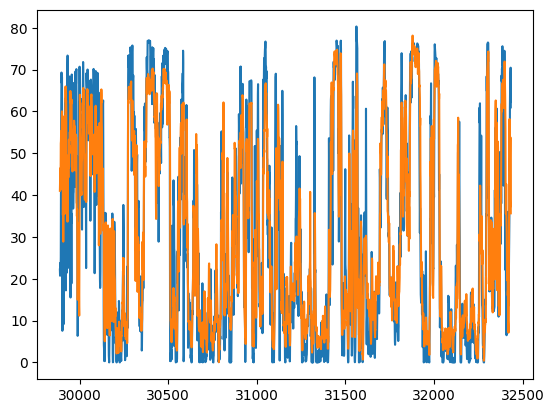

In [39]:
##TabM

tabm_params = {
    'batch_size': 'auto',
    'patience': 32,
    'allow_amp': True,
    'arch_type': 'tabm-mini',
    'tabm_k': 32,
    'gradient_clipping_norm': 1.0,
    'share_training_batches': False,
    'lr': 0.01,
    'weight_decay': 1e-4,
    'n_blocks': 3,
    'd_block': 32,
    'dropout': 0.5,
    'num_emb_type': 'pwl',
    'd_embedding': 16,
    'num_emb_n_bins': 75,
    "device": "cuda:0",
    "random_state": SEED
}
use_configuration = hill_climb_from_random_07_meta

categorical_features = []#["month", "toggle", "count_repair"]
numeric_features = [col for col in use_configuration if col not in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        )
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", ClipRegressor(
            TabM_D_Regressor(**tabm_params),
            low=0,
            up=88
            )
        ),
    ]
)

print("Start")
model.fit(train_model[use_configuration], train_model[TARGET_COL]) #24 минуты

pred = model.predict(val_model[use_configuration])
pred_train = model.predict(train_model[use_configuration])

plt.plot(val_model[TARGET_COL])
plt.plot(val_model.index, pred)
print(f"На трейне: {metric(train_model[TARGET_COL], pred_train)}") #8.63823811540306
print(f"На валидации: {metric(val_model[TARGET_COL], pred)}") #9.07586418077252

## TiDE

In [ ]:

lgb_params = {
        "objective": "mae",
        "n_estimators": 500,
        "learning_rate": 0.015468037883334,
        "num_leaves": 128,
        "subsample": 0.8614381770563153,
        "colsample_bytree": 0.8411016230697343,
        "reg_lambda": 55.13164984536291765,
        "reg_alpha": 52.664909586669296,
        "verbose": -1,
        "device": "cpu",#"cuda" if torch.cuda.is_available() else "cpu",
        "random_state": SEED
}
use_configuration = hill_climb_from_random
categorical_features = ["toggle", "count_repair"]
numeric_features = [col for col in use_configuration if col not in categorical_features]
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        )
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", ClipRegressor(
            lgb.LGBMRegressor(**lgb_params),
            low=0,
            up=90.09
            )
        ),
    ]
)
model.fit(train_model[use_configuration], train_model[TARGET_COL])
pred = model.predict(val_model[use_configuration])
pred_train = model.predict(train_model[use_configuration])
pred_valid = model.predict(valid[use_configuration])

plt.plot(val_model[TARGET_COL])
plt.plot(val_model.index, pred)
print(f"На трейне: {metric(train_model[TARGET_COL], pred_train)}") #8.132284672708193
print(f"На валидации: {metric(val_model[TARGET_COL], pred)}") #8.118925615154508

train["lgb_predict"] = np.concatenate([pred_train, pred])
valid["lgb_predict"] = pred_valid

In [ ]:
train["time_idx"] = np.arange(len(train))
percent_train = 0.8
length_train = int(percent_train * len(train))
train_model, val_model = train.iloc[:length_train], train.iloc[length_train:]
# Конфигурация
MAX_ENCODER_LENGTH = 840  # 7 дней истории (lookback)
MAX_PREDICTION_LENGTH = len(valid)  # 90 дней прогноза (Q1 2026)
max_time_idx = np.max(train["time_idx"])

# Признаки, известные в будущем (метеопрогноз)
known_reals = hill_climb_from_random_meta #+ ["lgb_predict"]
# Признаки, которые известны только из истории (таргет и его лаги)
lags = list(range(1, 2))
unknown_reals = [
    TARGET_COL
]# + [f"{TARGET_COL}_lag_{lag}" for lag in lags]

# Категориальные признаки
categoricals = ['month', 'hour_of_day', "toggle"]
known_reals = [col for col in known_reals if col not in categoricals]
for col in categoricals:
    train_model[col] = train_model[col].astype(int).astype(str).astype("category")
    val_model[col] = val_model[col].astype(int).astype(str).astype("category")


train_model["group_id"] = "A"
val_model["group_id"] = "A"

training = TimeSeriesDataSet(
    train_model,
    time_idx='time_idx',
    target=TARGET_COL,
    group_ids=['group_id'],
    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    min_encoder_length=MAX_ENCODER_LENGTH,
    min_prediction_length=MAX_PREDICTION_LENGTH,
   # lags={TARGET_COL: [1, 2, 3, 4, 5]},
    
    # Ковариаты
    time_varying_known_reals=known_reals,
    time_varying_known_categoricals=categoricals,
    time_varying_unknown_reals=unknown_reals,
    
    #target_normalizer=MultiNormalizer([
     #   EncoderNormalizer(method='standard', transformation='softplus'),
      #  EncoderNormalizer(method='standard', transformation='softplus')
    #]),
    
    # Нормализация target
    
    target_normalizer=GroupNormalizer(
        groups=['group_id'], 
        transformation='softplus'  # гарантирует положительность
    ),
    
    # Статические признаки (характеристики ВЭС)
    # static_categoricals=[...],      # страна, тип турбины
    # static_reals=['rated_power', ...],  # установленная мощность
    
    # Дополнительно
    add_relative_time_idx=False,
    add_target_scales=True,
    add_encoder_length=True
)

# Валидационный датасет
validation = TimeSeriesDataSet.from_dataset(
    training, 
    val_model, 
   # lags={TARGET_COL: [1, 2, 3, 4, 5]},
    stop_randomization=True
)

"""
class AugmentedTimeSeriesDataset(Dataset):
    def __init__(self, dataset, noise_std=0.01, noise_prob=0.3, noise_cols=None):
        self.dataset = dataset
        self.noise_std = noise_std
        self.noise_prob = noise_prob
        self.noise_cols = noise_cols  # индексы колонок в x_cont
        self.rng = np.random.default_rng()

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        x, y = self.dataset[idx]
        # проверяем содержимое y
        if isinstance(y, (tuple, list)):
            for i, yi in enumerate(y):
                if yi is None:
                    print(f"idx={idx}: y[{i}] is None")
                elif hasattr(yi, 'shape'):
                    print(f"idx={idx}: y[{i}] shape={yi.shape}")
        return x, y

count_x_cont = training[0][0]["x_cont"].shape[1]            #С единички, так как там столбец из 1.0, остальные норм
train_dataset = AugmentedTimeSeriesDataset(training, noise_std=0.01, noise_prob=0.1, noise_cols=np.arange(1, count_x_cont))
"""
# DataLoader'ы
batch_size = 32
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, shuffle=True, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

In [ ]:
class TimeDataset(Dataset):
    def __init__(self, data, target, len_seq, len_target, category_columns=[], n_lags_target=0, train=True):
        self.data = data
        self.target = target
        self.category_columns = category_columns
        self.n_lags_target = n_lags_target
        self.len_seq = len_seq

        ohe = OneHotEncoder()
        cat = ohe.fit_transform(self.data[category_columns]).toarray()
        cat_df = pd.DataFrame(cat, columns=ohe.get_feature_names_out(), index=self.data.index)
        self.data = pd.concat([self.data, cat_df], axis=1)
        self.data.drop(columns=category_columns, inplace=True)
        self.features = [col for col in self.data.columns if col != self.target] 
        
        for lag in range(1, self.n_lags_target + 1):
            self.data[f"{target}_lag_{lag}"] = self.data[target].shift(lag)
        self.data.dropna(inplace=True)

        if not train:
            print(f"Важно добавить {self.n_lags_target} точек из train")

    def __len__(self):
        return len(self.data) - len_seq

    def __getitem__(self, idx):
        data_seq = self.data[self.features].iloc[idx:idx + self.len_seq].values
        target_seq = self.data[self.target].iloc[idx:idx + self.len_seq].values
        return data_seq, target_seq


use_columns = lasso_01_features_plus_toggle
train_dataset = TimeDataset(data=train_model[use_columns + [TARGET_COL]], 
                            target=TARGET_COL,
                            category_columns=["toggle", "count_repair", "month", "hour_of_day"],
                            n_lags_target=5,
                            len_seq=128, 
                            len_target=len(valid),
                            train=True)
val_dataset = TimeDataset(
                    data=pd.concat([train_model.iloc[-5:], val_model], axis=0)[use_columns + [TARGET_COL]], 
                            target=TARGET_COL,
                            category_columns=["toggle", "count_repair", "month", "hour_of_day"],
                            n_lags_target=5,
                            len_seq=128, 
                            len_target=len(valid),
                            train=False)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
for batch in train_dataloader:
    x, y = batch
    for k, v in x.items():
        print(k)
    break

In [ ]:
for batch in train_dataloader:
    x, y = batch
    #print(x)
    if isinstance(x, dict):
        for k, v in x.items():
          #  print(k)
           # print(v)
            if type(v) is list:
                x[k] = [a.to(device) for a in v]
            else:
                x[k] = v.to(device)
        #x = {k: v.to(device) for k, v in x.items()}
    else:
        x = x.to(device)
    if type(y[0]) is list:
        y = torch.stack(y[0])
    else:
        y = y[0].to(device)
    print(y.device)
    for k, v in x.items():
        print(v.device)
    
    break

In [ ]:
# Создаём модель
tide = TiDEModel.from_dataset(
    training,
    hidden_size=128,
    output_size=256,
    num_encoder_layers=2,
    num_decoder_layers=2,
    temporal_decoder_hidden=256,
    dropout=0.5,
    loss=MAE()
)

epochs = 10
# Оптимизатор
optimizer = optim.Adam(tide.parameters(), lr=1e-4, weight_decay=5e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs,           # количество эпох для полного цикла
    eta_min=1e-5        # минимальный LR (по умолч. 0)
)

# Цикл обучения
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tide.to(device)

validation = True
for epoch in range(epochs):
    tide.train()
    total_loss = 0
    total_metric_train = 0
    
    for batch in train_dataloader:
        x, y = batch
        # Переносим на устройство
        if isinstance(x, dict):
            for k, v in x.items():
                #print(k)
                if type(v) is list:
                    x[k] = [a.to(device) for a in v]
                else:
                    x[k] = v.to(device)
            #x = {k: v.to(device) for k, v in x.items()}
        else:
            x = x.to(device)
        if type(y[0]) is list:
            y = y[0][0]
        else:
            y = y[0].to(device)
        
        # Forward
        #print(y.shape)
        optimizer.zero_grad()
        pred = tide(x).prediction
        #pred = pred[0]
        loss = MAE()(pred.cpu(), y.cpu())
        total_metric_train += metric(y.detach().cpu().numpy(), pred.detach().cpu().numpy()[:, :, 0])
        
        # Backward
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    if validation:
        # Валидация
        tide.eval()
        val_loss = 0
        total_metric_val = 0
        with torch.no_grad():
            for batch in val_dataloader:
                x, y = batch
                if isinstance(x, dict):
                    for k, v in x.items():
                        #print(k)
                        if type(v) is list:
                            x[k] = [a.to(device) for a in v]
                        else:
                            x[k] = v.to(device)
                    #x = {k: v.to(device) for k, v in x.items()}
                else:
                    x = x.to(device)
                if type(y[0]) is list:
                    y = y[0][0]#torch.stack(y[0])
                else:
                    y = y[0].to(device)
                
                pred = tide(x).prediction
              #  pred = pred[0]
                val_loss += MAE()(pred, y).item()
                total_metric_val += metric(y.detach().cpu().numpy(), pred.detach().cpu().numpy()[:, :, 0])
        

        avg_val_loss = val_loss / len(val_dataloader)
    avg_train_loss = total_loss / len(train_dataloader)    
    scheduler.step()
    
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Train metric: {total_metric_train / len(train_dataloader)}")
    if validation:
        print(f"  Val Loss:   {avg_val_loss:.4f}")
        print(f"  Val metric: {total_metric_val / len(val_dataloader)}")

In [ ]:
# Загружаем лучшую модель
"""
best_model = TiDEModel.load_from_checkpoint(
    trainer.checkpoint_callback.best_model_path
)
"""
# Подготавливаем данные для инференса
# Нужно взять последние 168 часов из истории + добавить будущие ковариаты
train_copy = pd.concat([train_model, val_model])
valid_copy = valid.copy()
for col in categoricals:
  #  train_copy[col] = train_copy[col].astype(str).astype("category")
    valid_copy[col] = valid_copy[col].astype(int).astype(str).astype("category")
# Данные для lookback (последние 168 часов из train + валидации)
last_known_data = train_copy[train_copy['time_idx'] >= max_time_idx - MAX_ENCODER_LENGTH]

# Будущие метеоданные на Q1 2026 уже есть в df_future
# df_future должен содержать те же колонки метео на 2160 часов

# Создаем датасет для прогноза
def create_prediction_data(last_data, future_data):
    """Соединяет историю и будущее для инференса"""
    combined = pd.concat([last_data, future_data], ignore_index=True)
    combined['time_idx'] = np.arange(
        last_data['time_idx'].min(),
        last_data['time_idx'].min() + len(combined)
    )
    combined['group_id'] = 'A'
    return combined

prediction_data = create_prediction_data(last_known_data, valid_copy)
#prediction_data.drop(columns=[TARGET_COL], inplace=True)
prediction_data[TARGET_COL].iloc[len(last_known_data):] = 0
# Создаем DataLoader
prediction_dataset = TimeSeriesDataSet.from_dataset(
    training,
    prediction_data,
    stop_randomization=True,
    predict=True  # Режим прогнозирования
) 

pred_dataloader = prediction_dataset.to_dataloader(
    train=False, 
    batch_size=1,  # Одна последовательность
    num_workers=0
)

# Прогноз
with torch.no_grad():
    predictions = tide.predict(
        pred_dataloader,
        mode='prediction',  # или 'quantiles' для интервалов
        return_x=False
    )

# Преобразуем в DataFrame
pred_df = pd.DataFrame({
    'power_prediction': predictions[0].numpy().flatten()[::-1]
})

# Пост-обработка: физические ограничения
pred_df = pred_df.clip(lower=0, upper=90.09)  # Мощность не может быть отрицательной
plt.plot(pred_df)
# Сохраняем
pred_df.to_csv('tide_base.csv', index=False)

## LSTM

In [ ]:
# Конфигурация
MAX_ENCODER_LENGTH = 128  # 7 дней истории (lookback)
MAX_PREDICTION_LENGTH = len(valid) # 90 дней прогноза (Q1 2026)
max_time_idx = np.max(train["time_idx"])

# Признаки, известные в будущем (метеопрогноз)
known_reals = lasso_01_features
# Признаки, которые известны только из истории (таргет и его лаги)
lags = list(range(1, 2))
unknown_reals = [
    TARGET_COL
]# + [f"{TARGET_COL}_lag_{lag}" for lag in lags]

# Категориальные признаки
categoricals = ['month', 'hour_of_day', "toggle"]
known_reals = [col for col in known_reals if col not in categoricals]
for col in categoricals:
    train_model[col] = train_model[col].astype(int).astype(str).astype("category")
    val_model[col] = val_model[col].astype(int).astype(str).astype("category")


train_model["group_id"] = "A"
val_model["group_id"] = "A"

training = TimeSeriesDataSet(
    train_model,
    time_idx='time_idx',
    target=TARGET_COL,
    group_ids=['group_id'],
    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    min_encoder_length=MAX_ENCODER_LENGTH,
    min_prediction_length=MAX_PREDICTION_LENGTH,
   # lags={TARGET_COL: [1, 2, 3, 4, 5]},
    
    # Ковариаты
    time_varying_known_reals=known_reals,
    time_varying_known_categoricals=categoricals,
    time_varying_unknown_reals=unknown_reals,
    
    #target_normalizer=MultiNormalizer([
     #   EncoderNormalizer(method='standard', transformation='softplus'),
      #  EncoderNormalizer(method='standard', transformation='softplus')
    #]),
    
    # Нормализация target
    
    target_normalizer=GroupNormalizer(
        groups=['group_id'], 
        transformation='softplus'  # гарантирует положительность
    ),
    
    # Статические признаки (характеристики ВЭС)
    # static_categoricals=[...],      # страна, тип турбины
    # static_reals=['rated_power', ...],  # установленная мощность
    
    # Дополнительно
    add_relative_time_idx=False,
    add_target_scales=True,
    add_encoder_length=True
)

# Валидационный датасет
validation = TimeSeriesDataSet.from_dataset(
    training, 
    val_model, 
   # lags={TARGET_COL: [1, 2, 3, 4, 5]},
    stop_randomization=True
)

"""
class AugmentedTimeSeriesDataset(Dataset):
    def __init__(self, dataset, noise_std=0.01, noise_prob=0.3, noise_cols=None):
        self.dataset = dataset
        self.noise_std = noise_std
        self.noise_prob = noise_prob
        self.noise_cols = noise_cols  # индексы колонок в x_cont
        self.rng = np.random.default_rng()

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        x, y = self.dataset[idx]
        # проверяем содержимое y
        if isinstance(y, (tuple, list)):
            for i, yi in enumerate(y):
                if yi is None:
                    print(f"idx={idx}: y[{i}] is None")
                elif hasattr(yi, 'shape'):
                    print(f"idx={idx}: y[{i}] shape={yi.shape}")
        return x, y

count_x_cont = training[0][0]["x_cont"].shape[1]            #С единички, так как там столбец из 1.0, остальные норм
train_dataset = AugmentedTimeSeriesDataset(training, noise_std=0.01, noise_prob=0.1, noise_cols=np.arange(1, count_x_cont))
"""
# DataLoader'ы
batch_size = 32
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, shuffle=True, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

In [ ]:
known_reals

In [ ]:
for batch in train_dataloader:
    x, y = batch
    print(x["encoder_cont"].shape)
    break

In [ ]:
# 1. Извлекаем данные из TimeSeriesDataSet
def extract_data(dataloader):
    """Извлекаем X (features) и y (target) из DataLoader"""
    X_list, y_list = [], []
    for batch in dataloader:
        x, y = batch
        # x['x_cont'] содержит все признаки (включая экзогенные)
        X_list.append(x['encoder_cont'].numpy())
        y_list.append(y[0].numpy())
    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

class LSTMDataset(Dataset):
    def __init__(self, data, len_seq, len_pred, target=TARGET_COL):
        self.data = data
        self.len_seq = len_seq
        self.len_pred = len_pred
        self.target=target
    
    def __len__(self):
        return len(self.data) - self.len_seq - self.len_pred

    def __getitem__(self, idx):
        feature_columns = [col for col in self.data.columns if col != self.target]
        X_hist = self.data.iloc[idx:idx + self.len_seq].values
        X_exog = self.data[feature_columns].iloc[idx + self.len_seq:idx + self.len_seq + self.len_pred].values
        y = self.data[self.target].iloc[idx + self.len_seq:idx + self.len_seq + self.len_pred].values
        return X_hist.astype(np.float32), X_exog.astype(np.float32), y.astype(np.float32)

train_percent = 0.8
train_len = int(train_percent * len(train))
train_data = train.iloc[:train_len]
val_data = train.iloc[train_len:]

use_columns = lasso_01_features
train_dataset = LSTMDataset(train_data[use_columns + [TARGET_COL]], len_seq=2048, len_pred=len(valid), target=TARGET_COL)
val_dataset = LSTMDataset(val_data[use_columns + [TARGET_COL]], len_seq=2048, len_pred=len(valid), target=TARGET_COL)

batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)
print(f"Train samples: {len(train_dataloader) * batch_size}")
print(f"Validation samples: {len(val_dataloader) * batch_size}")

In [ ]:
class LSTMWithExog(nn.Module):
    def __init__(self, hist_dim, exog_dim, hidden_dim=128, num_layers=2, pred_len=len(valid), dropout=0.3):
        super().__init__()
        self.pred_len = pred_len
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Энкодер: кодирует историю
        self.encoder_lstm = nn.LSTM(
            hist_dim, hidden_dim, num_layers, 
            batch_first=True, dropout=dropout
        )
        
        # Декодер: предсказывает последовательность
        self.decoder_lstm = nn.LSTM(
            exog_dim, hidden_dim, num_layers,
            batch_first=True, dropout=dropout
        )
        
        # Выходной слой
        self.fc_out = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x_hist, x_exog):
        """
        x_hist: (batch, hist_len, hist_dim) — исторические данные
        x_exog: (batch, pred_len, exog_dim) — будущие экзогенные переменные
        """
        batch_size = x_hist.size(0)
        
        # 1. Энкодер: кодируем историю
        encoder_out, (hidden, cell) = self.encoder_lstm(x_hist)
        # hidden: (num_layers, batch, hidden_dim)
        
        # 2. Декодер: предсказываем шаг за шагом
        decoder_input = x_exog[:, 0:1, :]  # первый вход для декодера
        outputs = []
        
        for t in range(self.pred_len):
            # Декодер
            decoder_out, (hidden, cell) = self.decoder_lstm(decoder_input, (hidden, cell))
            # decoder_out: (batch, 1, hidden_dim)
            
            # Предсказание на этом шаге
            pred = self.fc_out(decoder_out)  # (batch, 1, 1)
            outputs.append(pred)
            
            # Следующий вход: экзогенная переменная на следующий шаг
            if t + 1 < self.pred_len:
                decoder_input = x_exog[:, t+1:t+2, :]
        
        # Объединяем все предсказания
        outputs = torch.cat(outputs, dim=1)  # (batch, pred_len, 1)
        
        return outputs

X_hist_0, X_exog_0, y_0 = train_dataset[0]
hist_dim = X_hist_0.shape[1]
exog_dim = X_exog_0.shape[1]
pred_len = y_0.shape[0]

model = LSTMWithExog(
    hist_dim=hist_dim,
    exog_dim=exog_dim,
    hidden_dim=128,
    num_layers=2,
    pred_len=pred_len,
    dropout=0.25
)

print(f"History dim: {hist_dim}, Exogenious dim: {exog_dim}, Prediction length: {pred_len}")

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Оптимизатор и scheduler
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.1)

# Функция потерь
criterion = nn.L1Loss()  # MAE

# Цикл обучения
epochs = 10
best_val_loss = float('inf')

for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    
    for batch_x_hist, batch_x_exog, batch_y in train_dataloader:
        x_hist = batch_x_hist.to(device)
        x_exog = batch_x_exog.to(device)
        y = batch_y.to(device)
        optimizer.zero_grad()
        pred = model(x_hist, x_exog)[:, :, 0]
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    
    # Валидация
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch_x_hist, batch_x_exog, batch_y in val_dataloader:
            x_hist = batch_x_hist.to(device)
            x_exog = batch_x_exog.to(device)
            y = batch_y.to(device)
            
            val_pred = model(x_hist, x_exog)[:, :, 0]
            total_val_loss += criterion(val_pred, y).item()
    train_loss = total_train_loss / len(train_dataloader)
    val_loss = total_val_loss / len(val_dataloader)
    
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch+1}/{epochs}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss: {val_loss:.4f}")
    
    # Сохраняем лучшую модель
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_lstm.pth')

print(f"Best validation loss: {best_val_loss:.4f}")

In [ ]:
# Загрузка лучшей модели
model.load_state_dict(torch.load('best_lstm.pth'))
model.eval()

with torch.no_grad():
    train_pred = model(X_train_t).cpu().numpy()
    val_pred = model(X_val_t).cpu().numpy()

# Метрики
from sklearn.metrics import mean_absolute_error

train_mae = mean_absolute_error(y_train.flatten(), train_pred.flatten())
val_mae = mean_absolute_error(y_val.flatten(), val_pred.flatten())

print(f"Train MAE: {train_mae:.4f}")
print(f"Val MAE: {val_mae:.4f}")

# Нормализованная метрика (как в вашем соревновании)
N = 90.09
train_metric = train_mae / N * 100
val_metric = val_mae / N * 100
print(f"Train Metric: {train_metric:.2f}%")
print(f"Val Metric: {val_metric:.2f}%")

## Инференс (запускается строго после какой-то из ячеек модели)

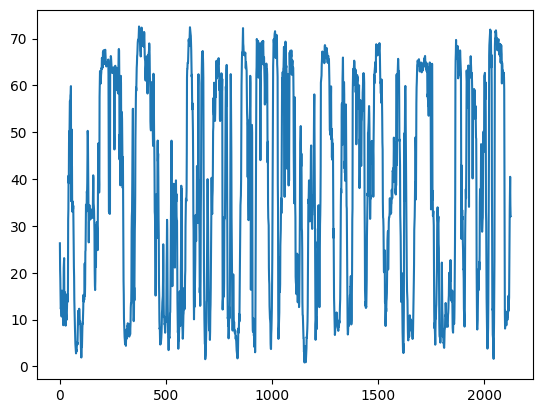

In [29]:
predict = model.predict(valid[use_configuration])
predict = predict[::-1] #так как в начале сортировали
plt.plot(predict)

In [30]:
predict_df = pd.DataFrame({"predict": predict})
save_path = "/kaggle/working/tabm_baseline.csv"

predict_df.to_csv(save_path, index=False)